# Daily validation diagnostics (Phase 0)

**Purpose:** Inspect *where* daily forecast error comes from **before** changing `energy_forecast` production code.

**What this notebook does:**
1. Resolves the repo root and imports the same `run_train_phase` path as the FastAPI app.
2. Runs one training pass (Mongo → hourly features → daily two-stage XGB → tuned threshold).
3. Builds a **per-day validation table** (`y`, `pred`, errors, calendar flags).
4. Computes **MAPE** (active days, matching `daily.validation_metrics`), **wMAPE**, and **median APE**.
5. Plots residuals vs actual level and vs month — patterns suggest next fixes (calibration vs weather vs XGB tuning).
6. **Optional:** fit a simple **linear calibration** `pred_cal = a * pred + b` on validation active days and report MAPE before/after (prototype only).

**Prerequisites:** Run Jupyter from the **repository root** *or* from `Scripts/` (the next cell adds the correct path). Set `MONGO_URI` / `METER_ID` / `ENERGY_MODEL_DIR` in the environment if needed — same as `energy_forecast.config.Settings.from_env()`.

In [1]:
# --- Imports & repo root on sys.path (works from repo root or Scripts/) ---
from __future__ import annotations

import sys
from pathlib import Path

_here = Path.cwd().resolve()
ROOT = _here
if (_here / "energy_forecast").is_dir():
    ROOT = _here
elif (_here.parent / "energy_forecast").is_dir():
    ROOT = _here.parent
else:
    raise RuntimeError(
        "Could not find energy_forecast/ — open Jupyter from repo root or Scripts/"
    )

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print  # noqa: A001 — fallback outside Jupyter

plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.25})

print("Repo root:", ROOT)

Repo root: E:\Projects\IOT-AI-Implementation


## 1. Run `run_train_phase` (same logic as API `/api/train`)

Uses `Settings.from_env()` — adjust env vars or edit defaults in `energy_forecast/config.py` for experiments.

> **Note:** First run loads Mongo and trains; it can take a minute depending on lookback and network.

In [2]:
from energy_forecast.config import Settings
from energy_forecast.train_phase import run_train_phase

settings = Settings.from_env()
print(
    "meter_id:", settings.meter_id,
    "| val_days:", settings.val_days,
    "| train_raw_lookback_days:", settings.train_raw_lookback_days,
)

tr = run_train_phase(settings)
val = tr.val_daily.copy()
metrics = tr.val_metrics

print("\n=== validation_metrics (package) ===")
for k in sorted(metrics.keys()):
    print(f"  {k}: {metrics[k]}")

meter_id: FUTU0000000004000002 | val_days: 31 | train_raw_lookback_days: 365

=== validation_metrics (package) ===
  classifier_accuracy: 1.0
  daily_mae: 28.43669179851017
  daily_mape_pct: 11.117316072923247
  daily_rmse: 56.525551153565694
  fn: 0
  fp: 0
  tp: 8
  val_actual_total_kwh: 8957.117234315025
  val_pred_total_kwh: 8936.3173828125
  val_total_error_pct: -0.23221591231205213


## 2. Per-day residual table (all validation days)

- **`pct_err`**: `abs(y - pred) / max(y, 1) * 100` — same spirit as `daily_mape_pct` aggregation (per-row then mean over active subset).
- **`signed_pct`**: `(pred - y) / max(y, 1) * 100` — see systematic over/under forecast.

Shutdown days often have `y` small; we still list them for context but **active-day MAPE** in the package excludes `is_active==0` from the MAPE mean.

In [3]:
def build_val_residual_table(val_df: pd.DataFrame) -> pd.DataFrame:
    """One row per validation day with errors and calendar context."""
    out = val_df.copy()
    out["abs_err_kwh"] = (out["y"] - out["pred"]).abs()
    denom = out["y"].clip(lower=1.0)
    out["pct_err"] = out["abs_err_kwh"] / denom * 100.0
    out["signed_pct"] = (out["pred"] - out["y"]) / denom * 100.0
    out["month"] = pd.to_datetime(out["ds"]).dt.month
    out["dow_name"] = pd.to_datetime(out["ds"]).dt.day_name()
    cols = [
        "ds",
        "y",
        "pred",
        "clf_active",
        "is_active",
        "clf_prob",
        "abs_err_kwh",
        "pct_err",
        "signed_pct",
        "is_holiday",
        "is_weekend",
        "dow",
        "dow_name",
        "month",
    ]
    if "day_type" in out.columns:
        cols.append("day_type")
    cols = [c for c in cols if c in out.columns]
    return out[cols].sort_values("ds")


tbl = build_val_residual_table(val)
display(tbl)

# Worst days by % error (among rows where y >= 50 kWh to avoid noise-dominated ratios)
active_like = tbl[tbl["y"] >= 50].copy()
worst = active_like.sort_values("pct_err", ascending=False).head(15)
print("\n=== Top 15 worst % error days (y >= 50 kWh) ===")
display(worst)

,ds,y,pred,clf_active,is_active,clf_prob,abs_err_kwh,pct_err,signed_pct,is_holiday,is_weekend,dow,dow_name,month,day_type
301,2026-03-11,421.191687,434.286713,1,1,0.999587,13.095026,3.109042,3.109042,0,0,2,Wednesday,3,working
302,2026-03-12,442.045718,434.286713,1,1,0.999829,7.759005,1.755249,-1.755249,0,0,3,Thursday,3,working
303,2026-03-13,350.178531,351.915649,1,1,0.999829,1.737118,0.496066,0.496066,0,0,4,Friday,3,working
304,2026-03-14,284.428571,284.428558,1,1,0.999829,0.000013,0.000005,-0.000005,0,1,5,Saturday,3,weekend
305,2026-03-15,20.800000,0.000000,0,0,0.237312,20.800000,100.000000,-100.000000,0,1,6,Sunday,3,weekend
306,2026-03-16,305.153333,305.153320,1,1,0.999587,0.000013,0.000004,-0.000004,0,0,0,Monday,3,working
307,2026-03-17,182.606667,182.606674,1,1,0.999707,0.000008,0.000004,0.000004,0,0,1,Tuesday,3,working
308,2026-03-18,0.000000,0.000000,0,0,0.029208,0.000000,0.000000,0.000000,0,0,2,Wednesday,3,working
309,2026-03-19,0.000000,0.000000,0,0,0.029208,0.000000,0.000000,0.000000,0,0,3,Thursday,3,working
310,2026-03-20,0.000000,0.000000,0,0,0.029208,0.000000,0.000000,0.000000,1,0,4,Friday,3,holiday



=== Top 15 worst % error days (y >= 50 kWh) ===


,ds,y,pred,clf_active,is_active,clf_prob,abs_err_kwh,pct_err,signed_pct,is_holiday,is_weekend,dow,dow_name,month,day_type
331,2026-04-10,139.712727,351.915649,1,1,0.999587,212.202922,151.885176,151.885176,0,0,4,Friday,4,working
322,2026-04-01,445.767000,351.915649,1,1,0.999829,93.851351,21.053903,-21.053903,0,0,2,Wednesday,4,working
313,2026-03-23,359.783099,434.286713,1,1,0.999587,74.503614,20.707925,20.707925,0,0,0,Monday,3,working
324,2026-04-03,429.240000,351.915649,1,1,0.999619,77.324351,18.014246,-18.014246,0,0,4,Friday,4,working
329,2026-04-08,506.680000,434.286713,1,1,0.999587,72.393287,14.287773,-14.287773,0,0,2,Wednesday,4,working
325,2026-04-04,394.680000,351.915649,1,1,0.999619,42.764351,10.835196,-10.835196,0,1,5,Saturday,4,weekend
328,2026-04-07,410.240000,428.196503,1,1,0.999829,17.956503,4.377073,4.377073,0,0,1,Tuesday,4,working
323,2026-04-02,446.153000,428.196503,1,1,0.999587,17.956497,4.024740,-4.024740,0,0,3,Thursday,4,working
301,2026-03-11,421.191687,434.286713,1,1,0.999587,13.095026,3.109042,3.109042,0,0,2,Wednesday,3,working
327,2026-04-06,442.840000,434.286713,1,1,0.999587,8.553287,1.931462,-1.931462,0,0,0,Monday,4,working


## 3. Summary metrics (compare to dashboard)

- **MAPE active (mean of pct_err):** should match `daily_mape_pct` when computed on the same `is_active==1` mask.
- **wMAPE:** `sum(abs_err) / sum(y)` over active days — one number, less sensitive to a few tiny denominators.
- **MdAPE:** median of per-day % errors — robust to outliers.

In [4]:
mask_active = val["is_active"] == 1
va = val.loc[mask_active]

if len(va) == 0:
    print("No active validation days.")
else:
    mape_mean = float(
        np.mean(np.abs((va["y"] - va["pred"]) / va["y"].clip(lower=1.0))) * 100.0
    )
    wmape = float(va["y"].sub(va["pred"]).abs().sum() / va["y"].sum() * 100.0)
    mdape = float(np.median(np.abs((va["y"] - va["pred"]) / va["y"].clip(lower=1.0))) * 100.0)

    print("Active validation days:", len(va))
    print("MAPE (mean %, package-style):", round(mape_mean, 4))
    print("wMAPE (%):                  ", round(wmape, 4))
    print("MdAPE (%):                  ", round(mdape, 4))
    print("Package daily_mape_pct:     ", metrics.get("daily_mape_pct"))

    # By month (active only)
    va2 = va.copy()
    va2["month"] = pd.to_datetime(va2["ds"]).dt.month
    print("\n=== wMAPE % by month (active days) ===")
    for m, g in va2.groupby("month"):
        w = float(g["y"].sub(g["pred"]).abs().sum() / g["y"].sum() * 100.0) if g["y"].sum() else np.nan
        print(f"  month {m:2d}: n={len(g):3d}  wMAPE={w:.2f}%")

    if "day_type" in va.columns:
        print("\n=== wMAPE % by day_type (active days) ===")
        for dt, g in va.groupby("day_type"):
            w = float(g["y"].sub(g["pred"]).abs().sum() / g["y"].sum() * 100.0) if g["y"].sum() else np.nan
            print(f"  {dt:8s}: n={len(g):3d}  wMAPE={w:.2f}%")

Active validation days: 23
MAPE (mean %, package-style): 11.1173
wMAPE (%):                   7.3189
MdAPE (%):                   1.7552
Package daily_mape_pct:      11.117316072923247

=== wMAPE % by month (active days) ===
  month  3: n= 14  wMAPE=2.09%
  month  4: n=  9  wMAPE=14.94%

=== wMAPE % by day_type (active days) ===
  weekend : n=  3  wMAPE=4.97%
  working : n= 20  wMAPE=7.57%


## 4. Plots — pattern hunt

- **Left:** `pred` vs `y` (ideal: diagonal). Off-diagonal bias → calibration or level shift.
- **Right:** residual (`pred - y`) vs `y` — if slope ≠ 0, model under/over-shoots high-load days.
- **Optional third:** boxplot of `pct_err` by month (uncomment in cell if desired).

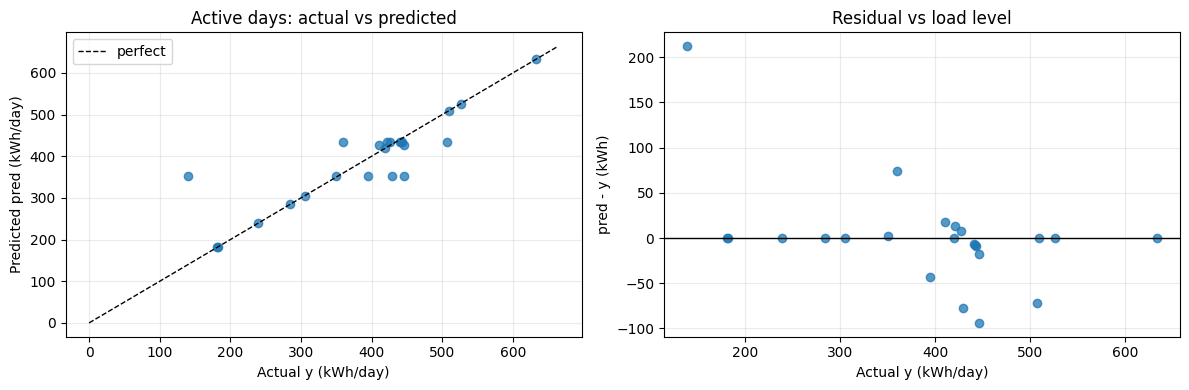

In [5]:
va = val.loc[val["is_active"] == 1]
if len(va) < 2:
    print("Not enough active days to plot.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ax0, ax1 = axes
    ax0.scatter(va["y"], va["pred"], alpha=0.75, s=36)
    lim = max(va["y"].max(), va["pred"].max()) * 1.05
    ax0.plot([0, lim], [0, lim], "k--", lw=1, label="perfect")
    ax0.set_xlabel("Actual y (kWh/day)")
    ax0.set_ylabel("Predicted pred (kWh/day)")
    ax0.set_title("Active days: actual vs predicted")
    ax0.legend()

    resid = va["pred"] - va["y"]
    ax1.scatter(va["y"], resid, alpha=0.75, s=36, c="tab:blue")
    ax1.axhline(0, color="k", lw=1)
    ax1.set_xlabel("Actual y (kWh/day)")
    ax1.set_ylabel("pred - y (kWh)")
    ax1.set_title("Residual vs load level")
    plt.tight_layout()
    plt.show()

    # --- Uncomment for month-wise spread ---
    # va_m = va.copy()
    # va_m["month"] = pd.to_datetime(va_m["ds"]).dt.month
    # plt.figure(figsize=(10, 4))
    # va_m.boxplot(column="pct_err", by="month", ax=plt.gca())
    # plt.suptitle("")
    # plt.title("Per-day % error by month (build tbl with pct_err on va)")
    # plt.show()

## 5. Optional — linear calibration on validation (active days only)

Fit `pred_cal = a * pred + b` minimizing **MAE** on `(pred_cal, y)`. This is a **prototype** for a future metadata-stored calibration step — **do not** treat `a,b` as production without walk-forward testing.

If MAPE drops a lot here but not in test folds, you are fixing **bias** not **generalization**.

Fitted: pred_cal = 1.0000 * pred + (0.00)
MAPE (mean %) before calibration: 11.117
MAPE (mean %) after calibration:  11.117


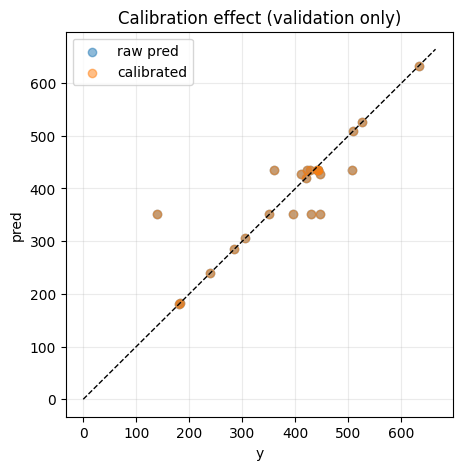

In [6]:
from sklearn.linear_model import LinearRegression

va = val.loc[val["is_active"] == 1]
if len(va) < 5:
    print("Need more active validation days for calibration demo.")
else:
    Xc = va[["pred"]].values
    yc = va["y"].values
    lr = LinearRegression(fit_intercept=True)
    lr.fit(Xc, yc)
    a, b = float(lr.coef_[0]), float(lr.intercept_)
    pred_cal = a * va["pred"].values + b

    mape_before = float(
        np.mean(np.abs((va["y"] - va["pred"]) / va["y"].clip(lower=1.0))) * 100.0
    )
    mape_after = float(
        np.mean(np.abs((va["y"] - pred_cal) / va["y"].clip(lower=1.0))) * 100.0
    )
    print(f"Fitted: pred_cal = {a:.4f} * pred + ({b:.2f})")
    print(f"MAPE (mean %) before calibration: {mape_before:.3f}")
    print(f"MAPE (mean %) after calibration:  {mape_after:.3f}")

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(va["y"], va["pred"], alpha=0.5, label="raw pred")
    ax.scatter(va["y"], pred_cal, alpha=0.5, label="calibrated")
    lim = max(va["y"].max(), pred_cal.max(), va["pred"].max()) * 1.05
    ax.plot([0, lim], [0, lim], "k--", lw=1)
    ax.set_xlabel("y")
    ax.set_ylabel("pred")
    ax.legend()
    ax.set_title("Calibration effect (validation only)")
    plt.show()

## 6. Next steps (after you read the tables/plots)

| Observation | Likely next implementation in `energy_forecast` |
|-------------|--------------------------------------------------|
| Points below diagonal in pred vs y (systematic under-prediction) | Recency ratio bounds, regressor depth/leaves, or **calibration** in metadata |
| Summer months much worse | Add **daily temperature / CDD** (Dubai) to `DAILY_FEATURES_*` + `build_daily_agg` |
| Few huge % errors, most days good | **MdAPE** reporting + robust loss or sample weights; check data on outlier dates |
| Weekends/holidays worse | Richer **day_type** / bridge-day flags beyond binary holiday |
| Linear calibration helps a lot | Persist `a,b` from a **proper CV** walk-forward, apply in `predict_daily_two_stage` |

When this notebook looks stable, port the **minimum** change (usually features or calibration) into the package and re-run `/api/train` metrics.